# Auto Insurance Fraud Detection

https://github.com/DandiMahendris/Auto-Insurance-Fraud-Detection?utm_source=chatgpt.com

| Column Name | Describe|
| --- | --- |
| Policy_annual_premium | Amount of insured need to pay over the year| 
| Insured_zip | Insured number |
| Capital-gains | Profit on earns of the sales |
| Capital-loss | Loss incurred |
| Incident_hour of the day | Hour of the day incident occurred |
| Total claim amount | Total Amount of claims |
| Injury claim | Amount of injury claims |
| Property claim | Amount of property claim |
| Vehicle claim | Amount of vehicle claim |
| Policy_state | State of policy holder |
| Policy_csl | Combined single limit of policy |
| Policy_deductable | Amount of first pay |
| Insured_sex | Gender |
| Insured_hobbies | Hobby of insured |
| Incident_type | Type of incident occurred |
| Collision_type | Type of damaged parts |
| Incident_severity | Type of severity damaged |
| Authorities contacted | Type of authorities has contacted on incident |
| Incident_state | State of incident |
| Incident_city | City of incident |
| Number of vehicle | Number of vehicle involved |
| Property damaged | Property damaged or not |
| Bodily injuries | Number of bodily injured |
| Witnesses | Number of witnesses |
| Auto_year | Year of auto model |
| Police_report | Available or not |
| Auto_make | Fabrication of Auto |
| Auto_model | Auto model |


In [33]:
import pandas as pd

ic = pd.read_csv("insurance_claims.csv")
ic['policy_number'] = ic['policy_number'].astype(str)
ic['insured_zip'] = ic['insured_zip'].astype(str)
ic['policy_bind_date'] = pd.to_datetime(ic['policy_bind_date'])
ic['incident_date'] = pd.to_datetime(ic['incident_date'])
ic = ic.drop('_c39', axis=1)

## Data Validation and Basic Adjustments

In [34]:
ic.columns[ic.isnull().any()]

Index(['authorities_contacted'], dtype='object')

In [35]:
ic['authorities_contacted'].unique()

array(['Police', nan, 'Fire', 'Other', 'Ambulance'], dtype=object)

No need to concern, we can convert `authorities_contacted` into dummy variables later.

In [36]:
ic.loc[ic['collision_type'] == '?', 'collision_type'] = pd.NA
ic.loc[ic['property_damage'] == '?', 'property_damage'] = pd.NA
ic.loc[ic['police_report_available'] == '?', 'police_report_available'] = pd.NA
ic['property_damage'] = ic['property_damage'].map({'YES': 1, 'NO': 0})
ic['police_report_available'] = ic['police_report_available'].map({'YES': 1, 'NO': 0})
ic['fraud_reported'] = ic['fraud_reported'].map({'Y': 1, 'N': 0})
ic['incident_location_type'] = ic['incident_location'].str.rsplit(' ', n=1).str[-1]

## Exploratory Data Analysis

In [37]:
ic['fraud_reported'].value_counts(normalize=True) * 100

fraud_reported
0    75.3
1    24.7
Name: proportion, dtype: float64

<Axes: xlabel='fraud_reported', ylabel='count'>

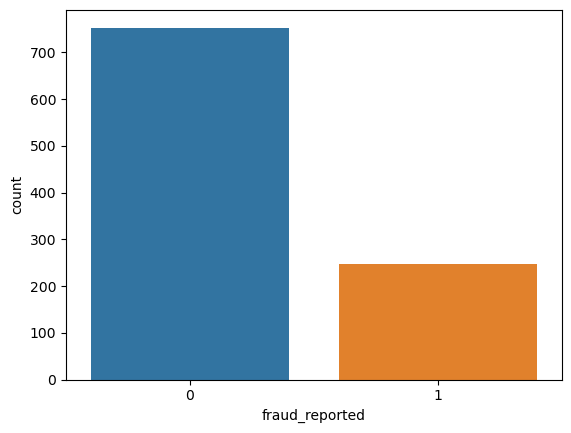

In [38]:
import seaborn as sns

sns.countplot(x='fraud_reported', data=ic)

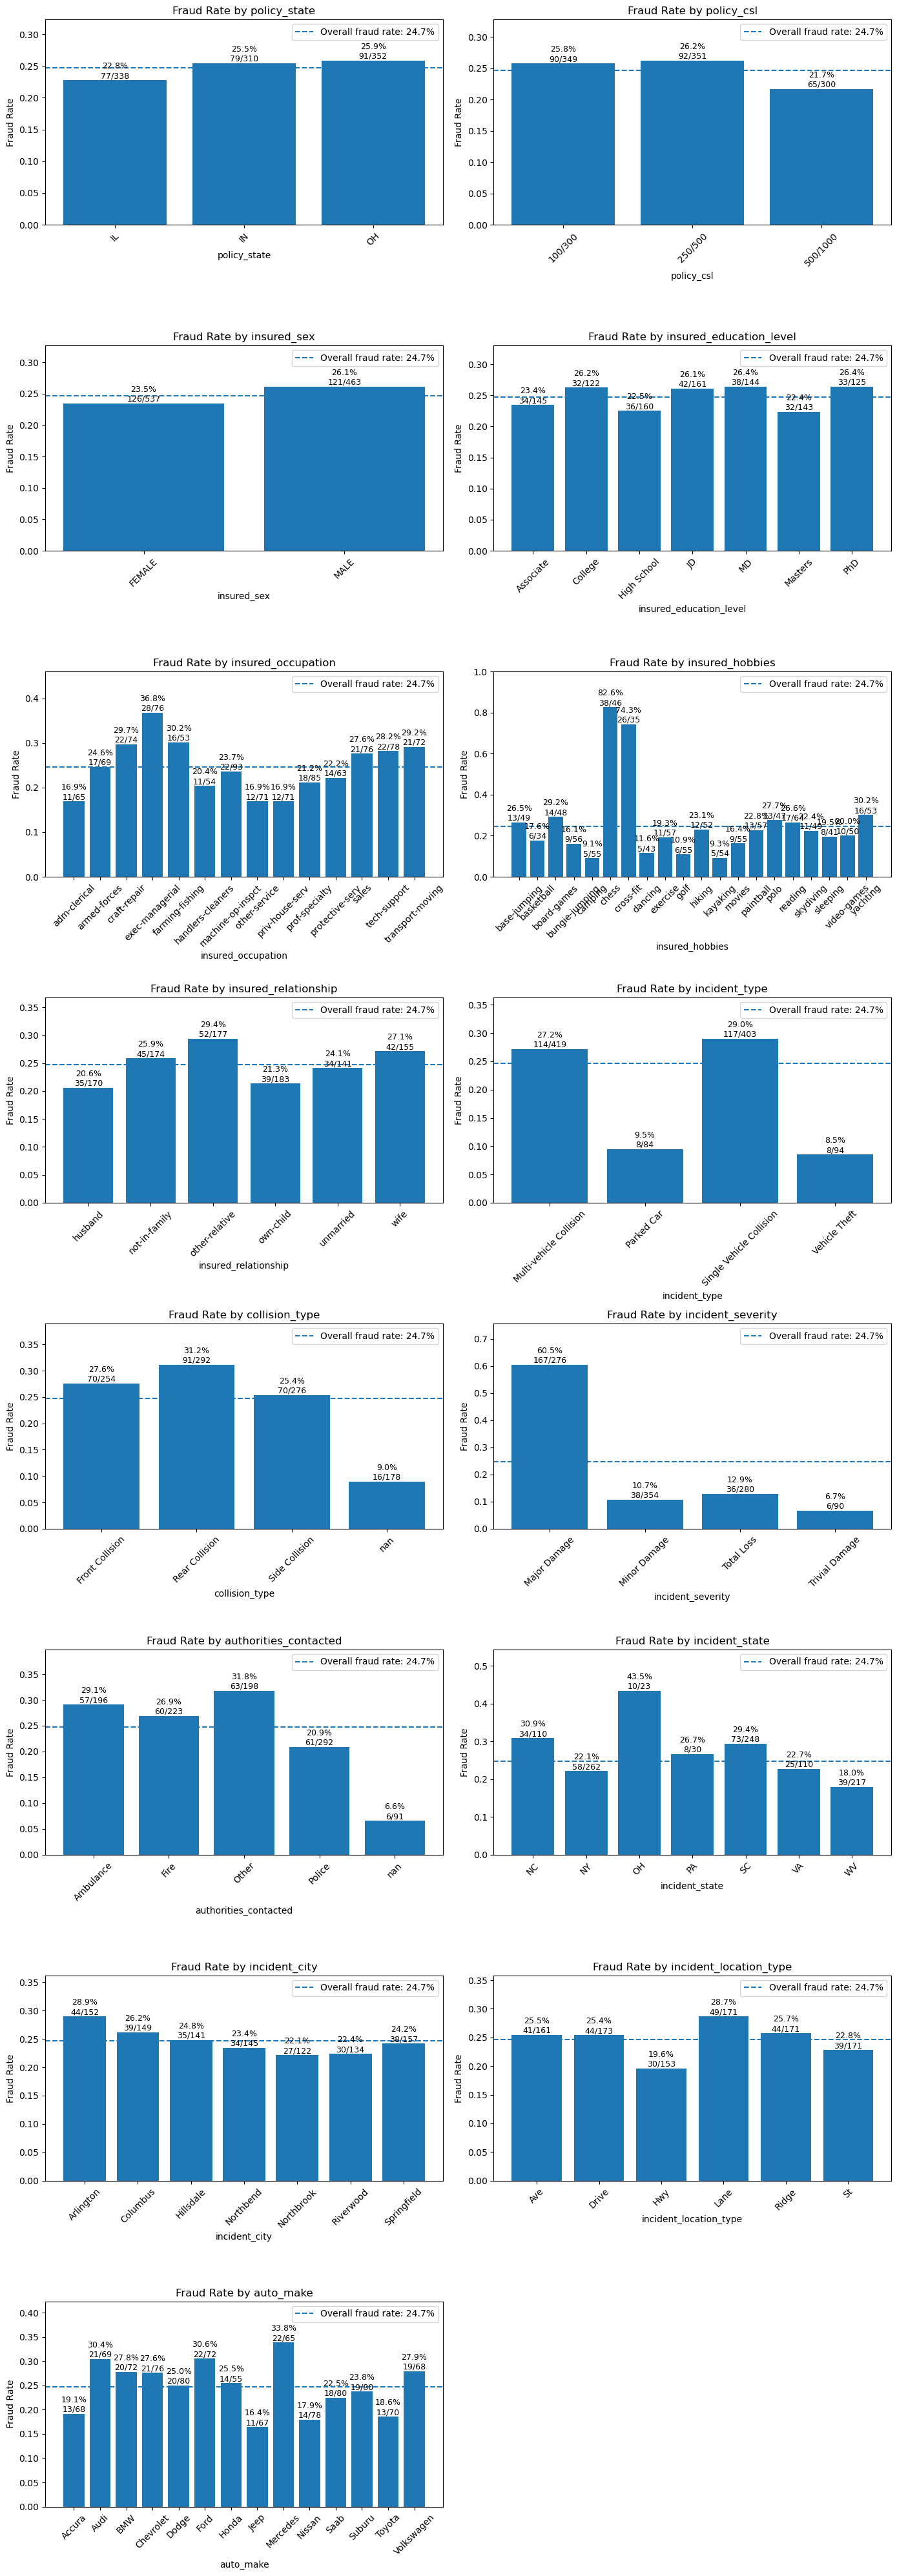

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_fraud_rates_by_category(
    data,
    categorical_vars,
    target='fraud_reported',
    ncols=2,
    figsize_per_plot=(7, 5)
):
    overall_fraud_rate = data[target].mean()

    nrows = math.ceil(len(categorical_vars) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(
            figsize_per_plot[0] * ncols,
            figsize_per_plot[1] * nrows
        )
    )

    axes = np.array(axes).reshape(-1)

    for ax, variable in zip(axes, categorical_vars):

        summary = (
            data.groupby(variable, dropna=False)[target]
            .agg(
                fraud_rate='mean',
                fraud_count='sum',
                sample_size='count'
            )
            .reset_index()
        )

        bars = ax.bar(
            summary[variable].astype(str),
            summary['fraud_rate']
        )

        ax.axhline(
            overall_fraud_rate,
            linestyle='--',
            linewidth=1.5,
            label=f'Overall fraud rate: {overall_fraud_rate:.1%}'
        )

        for bar, fraud_rate, fraud_count, sample_size in zip(
            bars,
            summary['fraud_rate'],
            summary['fraud_count'],
            summary['sample_size']
        ):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f'{fraud_rate:.1%}\n{int(fraud_count)}/{int(sample_size)}',
                ha='center',
                va='bottom',
                fontsize=9
            )

        ax.set_title(f'Fraud Rate by {variable}')
        ax.set_xlabel(variable)
        ax.set_ylabel('Fraud Rate')

        ax.set_ylim(
            0,
            min(
                1,
                max(summary['fraud_rate'].max() * 1.25, overall_fraud_rate * 1.25)
            )
        )

        ax.tick_params(axis='x', rotation=45)
        ax.legend()

    for ax in axes[len(categorical_vars):]:
        ax.remove()

    plt.tight_layout()
    plt.show()


categorical_vars = [
    'policy_state'
    ,'policy_csl'
    ,'insured_sex'
    ,'insured_education_level'
    ,'insured_occupation'
    ,'insured_hobbies'
    ,'insured_relationship'
    ,'incident_type'
    ,'collision_type'
    ,'incident_severity'
    ,'authorities_contacted'
    ,'incident_state'
    ,'incident_city'
    ,'incident_location_type'
    ,'auto_make'
]

plot_fraud_rates_by_category(
    ic,
    categorical_vars
)

#### Dummy variables required:
- `policy_state`: 
    - 'IL'
- `policy_csl`:
    - '500/1000'
- `insured_sex`: 
    - 'FEMALE'
- `insured_education_level`: 
    - 'Associate' 
    - 'High School'
    - 'Masters'
- `insured_occupation`: 
    - 'exec-managerial'
    - Low Risk: 'adm-clerical', 'other-service', 'priv-house-serv'
- `insured_hobbies`:
    - 'chess'
    - 'cross-fit'
    - Low Risk: 'camping', 'dancing', 'golf', 'kayaking'
- `insured_relationship`:
    - 'other-relative'
    - 'husband'
    - 'own-child'
- `incident_type`:
    - 'Parked Car'
    - 'Single Vehicle Collision'
    - 'Vehicle Theft'
- `collision_type`:
    - 'Front Collision'
    - 'Rear Collision'
- `incident_severity`:
    - 'Major Damage'
    - 'Trivial Damage'
- `authorities_contacted`:
    - 'Other'
    - isnull
- `incident_state`:
    - 'OH'
    - 'WV'
- `incident_city`:
    - 'Arlington'
- `incident_location_type`:
    - 'Hwy'
    - 'Lane'
- `auto_make`:
    - High Risk: 'Audi', 'Mercedes', 'Ford'
    - Low Risk: 'Accura', 'Jeep', 'Nissan', 'Toyota'

In [40]:
from scipy.stats import chi2_contingency

education_table = pd.crosstab(
    ic['insured_education_level'],
    ic['fraud_reported']
)

chi2, p_value, dof, expected = chi2_contingency(education_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.4f}")

Chi-square statistic: 1.688
P-value: 0.9460


#### Dummy Variables
- `df` being the data frame that adds dummy variables

In [41]:
import pandas as pd

# Create a working copy
df = ic.copy()

# ---------------------------------------------------------
# Policy features
# ---------------------------------------------------------

df['policy_state_IL'] = (df['policy_state'] == 'IL').astype('int8')

df['policy_csl_500_1000'] = (
    df['policy_csl'] == '500/1000'
).astype('int8')


# ---------------------------------------------------------
# Insured demographic features
# ---------------------------------------------------------

df['insured_sex_FEMALE'] = (
    df['insured_sex'] == 'FEMALE'
).astype('int8')

df['education_Associate'] = (
    df['insured_education_level'] == 'Associate'
).astype('int8')

df['education_High_School'] = (
    df['insured_education_level'] == 'High School'
).astype('int8')

df['education_Masters'] = (
    df['insured_education_level'] == 'Masters'
).astype('int8')


# ---------------------------------------------------------
# Occupation features
# ---------------------------------------------------------

df['occupation_exec_managerial'] = (
    df['insured_occupation'] == 'exec-managerial'
).astype('int8')

low_risk_occupations = [
    'adm-clerical',
    'other-service',
    'priv-house-serv'
]

df['occupation_low_risk'] = (
    df['insured_occupation'].isin(low_risk_occupations)
).astype('int8')


# ---------------------------------------------------------
# Hobby features
# ---------------------------------------------------------

df['hobby_chess'] = (
    df['insured_hobbies'] == 'chess'
).astype('int8')

df['hobby_cross_fit'] = (
    df['insured_hobbies'] == 'cross-fit'
).astype('int8')

low_risk_hobbies = [
    'camping',
    'dancing',
    'golf',
    'kayaking'
]

df['hobby_low_risk'] = (
    df['insured_hobbies'].isin(low_risk_hobbies)
).astype('int8')


# ---------------------------------------------------------
# Relationship features
# ---------------------------------------------------------

df['relationship_other_relative'] = (
    df['insured_relationship'] == 'other-relative'
).astype('int8')

df['relationship_husband'] = (
    df['insured_relationship'] == 'husband'
).astype('int8')

df['relationship_own_child'] = (
    df['insured_relationship'] == 'own-child'
).astype('int8')


# ---------------------------------------------------------
# Incident type features
# ---------------------------------------------------------

df['incident_type_Parked_Car'] = (
    df['incident_type'] == 'Parked Car'
).astype('int8')

df['incident_type_Single_Vehicle_Collision'] = (
    df['incident_type'] == 'Single Vehicle Collision'
).astype('int8')

df['incident_type_Vehicle_Theft'] = (
    df['incident_type'] == 'Vehicle Theft'
).astype('int8')


# ---------------------------------------------------------
# Collision type features
# ---------------------------------------------------------

df['collision_type_Front_Collision'] = (
    df['collision_type'] == 'Front Collision'
).astype('int8')

df['collision_type_Rear_Collision'] = (
    df['collision_type'] == 'Rear Collision'
).astype('int8')


# ---------------------------------------------------------
# Incident severity features
# ---------------------------------------------------------

df['incident_severity_Major_Damage'] = (
    df['incident_severity'] == 'Major Damage'
).astype('int8')

df['incident_severity_Trivial_Damage'] = (
    df['incident_severity'] == 'Trivial Damage'
).astype('int8')


# ---------------------------------------------------------
# Authorities contacted features
# ---------------------------------------------------------

df['authorities_contacted_Other'] = (
    df['authorities_contacted'] == 'Other'
).astype('int8')

df['authorities_contacted_missing'] = (
    df['authorities_contacted'].isna()
).astype('int8')


# ---------------------------------------------------------
# Incident state features
# ---------------------------------------------------------

df['incident_state_OH'] = (
    df['incident_state'] == 'OH'
).astype('int8')

df['incident_state_WV'] = (
    df['incident_state'] == 'WV'
).astype('int8')


# ---------------------------------------------------------
# Incident city features
# ---------------------------------------------------------

df['incident_city_Arlington'] = (
    df['incident_city'] == 'Arlington'
).astype('int8')


# ---------------------------------------------------------
# Incident location type features
# ---------------------------------------------------------

df['incident_location_type_Hwy'] = (
    df['incident_location_type'] == 'Hwy'
).astype('int8')

df['incident_location_type_Lane'] = (
    df['incident_location_type'] == 'Lane'
).astype('int8')


# ---------------------------------------------------------
# Auto make features
# ---------------------------------------------------------

high_risk_auto_makes = [
    'Audi',
    'Mercedes',
    'Ford'
]

low_risk_auto_makes = [
    'Accura',
    'Jeep',
    'Nissan',
    'Toyota'
]

df['auto_make_high_risk'] = (
    df['auto_make'].isin(high_risk_auto_makes)
).astype('int8')

df['auto_make_low_risk'] = (
    df['auto_make'].isin(low_risk_auto_makes)
).astype('int8')


dummy_columns = [
    'policy_state_IL',
    'policy_csl_500_1000',
    'insured_sex_FEMALE',
    'education_Associate',
    'education_High_School',
    'education_Masters',
    'occupation_exec_managerial',
    'occupation_low_risk',
    'hobby_chess',
    'hobby_cross_fit',
    'hobby_low_risk',
    'relationship_other_relative',
    'relationship_husband',
    'relationship_own_child',
    'incident_type_Parked_Car',
    'incident_type_Single_Vehicle_Collision',
    'incident_type_Vehicle_Theft',
    'collision_type_Front_Collision',
    'collision_type_Rear_Collision',
    'incident_severity_Major_Damage',
    'incident_severity_Trivial_Damage',
    'authorities_contacted_Other',
    'authorities_contacted_missing',
    'incident_state_OH',
    'incident_state_WV',
    'incident_city_Arlington',
    'incident_location_type_Hwy',
    'incident_location_type_Lane',
    'auto_make_high_risk',
    'auto_make_low_risk'
]

df[dummy_columns].sum().sort_values()

incident_state_OH                          23
hobby_cross_fit                            35
hobby_chess                                46
occupation_exec_managerial                 76
incident_type_Parked_Car                   84
incident_severity_Trivial_Damage           90
authorities_contacted_missing              91
incident_type_Vehicle_Theft                94
education_Masters                         143
education_Associate                       145
incident_city_Arlington                   152
incident_location_type_Hwy                153
education_High_School                     160
relationship_husband                      170
incident_location_type_Lane               171
relationship_other_relative               177
relationship_own_child                    183
authorities_contacted_Other               198
auto_make_high_risk                       206
hobby_low_risk                            207
occupation_low_risk                       207
incident_state_WV                 

#### Cyclical Encoding
$$cos(2*\pi*t/24)$$

In [42]:
import numpy as np

df['incident_hour_sin'] = np.sin(
    2 * np.pi * df['incident_hour_of_the_day'] / 24
)

df['incident_hour_cos'] = np.cos(
    2 * np.pi * df['incident_hour_of_the_day'] / 24
)

#### Macroeconomic Indicator
Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma (DCOILWTICO)
<https://fred.stlouisfed.org/series/dcoilwtico?utm_source=chatgpt.com>

In [43]:
wti = pd.read_csv("DCOILWTICO.csv")
wti['observation_date'] = pd.to_datetime(wti['observation_date'])
df['incident_date'] = pd.to_datetime(df['incident_date'])

wti['DCOILWTICO'] = pd.to_numeric(
    wti['DCOILWTICO'],
    errors='coerce'
)

wti = wti[
    wti['observation_date'].between(
        '2015-01-01',
        '2015-03-01'
    )
]

df = df.merge(
    wti[['observation_date', 'DCOILWTICO']],
    how='left',
    left_on='incident_date',
    right_on='observation_date'
)

df = df.drop(columns='observation_date')

df = df.rename(
    columns={'DCOILWTICO': 'wti_price'}
)

df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,incident_state_OH,incident_state_WV,incident_city_Arlington,incident_location_type_Hwy,incident_location_type_Lane,auto_make_high_risk,auto_make_low_risk,incident_hour_sin,incident_hour_cos,wti_price
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,0,0,0,0,0,0,0,0.965926,0.258819,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,0,0,1,0,1,0,0.866025,-0.500000,47.85
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,0,0,0,0,1,0,0,0.965926,-0.258819,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,1,0,1,0,0,0,0,0.965926,0.258819,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,0,0,1,0,0,0,1,-0.866025,0.500000,53.56


#### Drop Categorical Columns

In [44]:
from sklearn.model_selection import train_test_split

drop_identifier_cols = [
    'policy_number'
    ,'incident_location'
    ,'insured_zip'
]

drop_categorical_cols = [
    #'policy_number',
    'policy_bind_date'
    ,'policy_state'
    ,'policy_csl'
    ,'insured_sex'
    ,'insured_education_level'
    ,'insured_occupation'
    ,'insured_hobbies'
    ,'insured_relationship'
    ,'incident_date'
    ,'incident_type'
    ,'collision_type'
    ,'incident_severity'
    ,'authorities_contacted'
    ,'incident_state'
    ,'incident_city'
    ,'auto_make'
    ,'auto_model'
    ,'incident_location_type'
]

X = df.drop(
    columns=[
        'fraud_reported'
    ] + drop_identifier_cols + drop_categorical_cols
)

y = df['fraud_reported']

print(X.shape)
print(X.dtypes)
print(X.isna().sum().sort_values(ascending=False).head(20))
X.select_dtypes(include='object').columns

(1000, 51)
months_as_customer                          int64
age                                         int64
policy_deductable                           int64
policy_annual_premium                     float64
umbrella_limit                              int64
capital-gains                               int64
capital-loss                                int64
incident_hour_of_the_day                    int64
number_of_vehicles_involved                 int64
property_damage                           float64
bodily_injuries                             int64
witnesses                                   int64
police_report_available                   float64
total_claim_amount                          int64
injury_claim                                int64
property_claim                              int64
vehicle_claim                               int64
auto_year                                   int64
policy_state_IL                              int8
policy_csl_500_1000                    

Index([], dtype='object')

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

#### XGBoost Baseline Model

In [46]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [47]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
importance

incident_severity_Major_Damage            0.137806
hobby_chess                               0.086293
hobby_cross_fit                           0.073925
hobby_low_risk                            0.028565
education_High_School                     0.023779
incident_type_Single_Vehicle_Collision    0.022086
vehicle_claim                             0.021217
education_Masters                         0.019889
relationship_own_child                    0.018464
incident_hour_cos                         0.018291
policy_annual_premium                     0.016786
incident_state_WV                         0.016510
umbrella_limit                            0.016438
witnesses                                 0.016421
police_report_available                   0.016322
auto_make_low_risk                        0.016179
wti_price                                 0.016079
policy_csl_500_1000                       0.015924
injury_claim                              0.015874
incident_city_Arlington        

#### Permutation Importance

In [48]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    xgb_model,
    X_train,
    y_train,
    scoring='average_precision',
    n_repeats=20,
    random_state=42
)

perm_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values(
    'importance_mean',
    ascending=False
)

perm_importance['lower_bound'] = (
    perm_importance['importance_mean']
    - perm_importance['importance_std']
)

selected_features = perm_importance.loc[
    perm_importance['lower_bound'] > 0,
    'feature'
].tolist()

perm_importance

,feature,importance_mean,importance_std,lower_bound
37,incident_severity_Major_Damage,0.288154,0.019114,0.269039
26,hobby_chess,0.213397,0.025855,0.187542
27,hobby_cross_fit,0.082645,0.010412,0.072233
28,hobby_low_risk,0.010512,0.002421,0.008091
15,property_claim,0.009271,0.002431,0.006840
3,policy_annual_premium,0.007911,0.001519,0.006392
17,auto_year,0.007807,0.001632,0.006175
5,capital-gains,0.004386,0.000777,0.003610
13,total_claim_amount,0.004331,0.001142,0.003189
50,wti_price,0.004285,0.000907,0.003379


#### Cross Validation
1. All variables
2. All non-zero features
3. $Value > mean - std$
4. Features $> max/100$

In [49]:
all_features = perm_importance['feature'].tolist()

nonzero_features = perm_importance.loc[
    perm_importance['importance_mean'] > 0,
    'feature'
].tolist()

stable_features = perm_importance.loc[
    perm_importance['importance_mean']
    - perm_importance['importance_std'] > 0,
    'feature'
].tolist()

cutoff = perm_importance['importance_mean'].max() / 100

top_features = perm_importance.loc[
    perm_importance['importance_mean'] > cutoff,
    'feature'
].tolist()

from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import pandas as pd

feature_sets = {
    'All': all_features,
    'Non-zero': nonzero_features,
    'Stable': stable_features,
    'Max/100': top_features
}

results = []

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, features in feature_sets.items():

    model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train[features],
        y_train,
        scoring='average_precision',
        cv=cv
    )

    results.append({
        'Feature_Set': name,
        'Number_of_Features': len(features),
        'Mean_PR_AUC': scores.mean(),
        'Std_PR_AUC': scores.std()
    })

comparison = pd.DataFrame(results)

comparison

,Feature_Set,Number_of_Features,Mean_PR_AUC,Std_PR_AUC
0,All,51,0.690870,0.078641
1,Non-zero,47,0.686888,0.074973
2,Stable,44,0.694570,0.063384
3,Max/100,12,0.737223,0.032080


#### Comparing Full Model vs Max/100 Model

In [50]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from xgboost import XGBClassifier
import pandas as pd

feature_sets = {
    'All_51': X_train.columns.tolist(),
    'Selected_12': top_features
}

test_results = []

final_models = {}

for name, features in feature_sets.items():

    model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42
    )

    model.fit(
        X_train[features],
        y_train
    )

    prob = model.predict_proba(
        X_test[features]
    )[:, 1]

    pred = (prob >= 0.5).astype(int)

    test_results.append({
        'Model': name,
        'Number_of_Features': len(features),
        'PR_AUC': average_precision_score(y_test, prob),
        'ROC_AUC': roc_auc_score(y_test, prob),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred)
    })

    final_models[name] = model

test_comparison = pd.DataFrame(test_results)

test_comparison

,Model,Number_of_Features,PR_AUC,ROC_AUC,Precision,Recall,F1
0,All_51,51,0.593968,0.844574,0.619048,0.530612,0.571429
1,Selected_12,12,0.540763,0.817543,0.538462,0.428571,0.477273


#### Using Stable Features as final model

In [51]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Validate selected features
# ---------------------------------------------------------

stable_features = list(stable_features)

missing_features = [
    feature
    for feature in stable_features
    if feature not in X_train.columns
]

if missing_features:
    raise ValueError(
        f"Missing features in X_train: {missing_features}"
    )

print(f"Number of stable features: {len(stable_features)}")


# ---------------------------------------------------------
# Prepare modelling datasets
# ---------------------------------------------------------

X_train_final = X_train[stable_features].copy()
X_test_final = X_test[stable_features].copy()


# ---------------------------------------------------------
# Build final XGBoost model
# ---------------------------------------------------------

final_xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)


# ---------------------------------------------------------
# Train final model
# ---------------------------------------------------------

final_xgb_model.fit(
    X_train_final,
    y_train
)


# ---------------------------------------------------------
# Generate predictions
# ---------------------------------------------------------

y_test_probability = final_xgb_model.predict_proba(
    X_test_final
)[:, 1]

default_threshold = 0.50

y_test_prediction = (
    y_test_probability >= default_threshold
).astype(int)


# ---------------------------------------------------------
# Evaluate final model
# ---------------------------------------------------------

final_metrics = pd.DataFrame({
    'Metric': [
        'PR-AUC',
        'ROC-AUC',
        'Accuracy',
        'Precision',
        'Recall',
        'F1'
    ],
    'Value': [
        average_precision_score(
            y_test,
            y_test_probability
        ),
        roc_auc_score(
            y_test,
            y_test_probability
        ),
        accuracy_score(
            y_test,
            y_test_prediction
        ),
        precision_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        f1_score(
            y_test,
            y_test_prediction,
            zero_division=0
        )
    ]
})

print(final_metrics)


# ---------------------------------------------------------
# Confusion matrix
# ---------------------------------------------------------

confusion = pd.DataFrame(
    confusion_matrix(
        y_test,
        y_test_prediction
    ),
    index=[
        'Actual Non-Fraud',
        'Actual Fraud'
    ],
    columns=[
        'Predicted Non-Fraud',
        'Predicted Fraud'
    ]
)

print("\nConfusion Matrix:")
print(confusion)


# ---------------------------------------------------------
# Classification report
# ---------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_prediction,
        digits=3,
        zero_division=0
    )
)

Number of stable features: 44
      Metric     Value
0     PR-AUC  0.582959
1    ROC-AUC  0.841060
2   Accuracy  0.800000
3  Precision  0.609756
4     Recall  0.510204
5         F1  0.555556

Confusion Matrix:
                  Predicted Non-Fraud  Predicted Fraud
Actual Non-Fraud                  135               16
Actual Fraud                       24               25

Classification Report:
              precision    recall  f1-score   support

           0      0.849     0.894     0.871       151
           1      0.610     0.510     0.556        49

    accuracy                          0.800       200
   macro avg      0.729     0.702     0.713       200
weighted avg      0.790     0.800     0.794       200



In [52]:
prediction_results = df.loc[
    X_test.index
].copy()

prediction_results['actual_fraud'] = y_test

prediction_results['fraud_probability'] = (
    y_test_probability
)

prediction_results['predicted_fraud_050'] = (
    y_test_prediction
)

prediction_results = prediction_results.sort_values(
    'fraud_probability',
    ascending=False
)

prediction_results.head(20)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,incident_location_type_Hwy,incident_location_type_Lane,auto_make_high_risk,auto_make_low_risk,incident_hour_sin,incident_hour_cos,wti_price,actual_fraud,fraud_probability,predicted_fraud_050
919,188,33,457188,1994-04-01,IL,250/500,1000,1340.24,0,447274,...,0,0,0,0,8.660254e-01,-5.000000e-01,NaN,1,0.949392,1
183,86,26,391652,1998-10-12,OH,100/300,500,1382.88,7000000,434923,...,0,0,0,0,2.588190e-01,-9.659258e-01,46.06,1,0.936914,1
56,439,56,524836,2008-11-20,IN,250/500,500,1082.49,0,606714,...,1,0,0,0,1.224647e-16,-1.000000e+00,NaN,0,0.914045,1
552,360,51,550294,2001-11-26,IL,500/1000,1000,1526.61,0,471866,...,0,0,0,0,9.659258e-01,2.588190e-01,47.79,1,0.896985,1
561,272,41,337158,1991-04-08,OH,250/500,2000,945.73,5000000,435663,...,1,0,1,0,-2.588190e-01,9.659258e-01,48.45,1,0.879333,1
888,381,55,963761,1991-04-13,OH,500/1000,500,1459.99,0,445856,...,0,0,0,1,8.660254e-01,-5.000000e-01,46.06,0,0.868859,1
914,140,36,117862,2000-07-14,OH,500/1000,2000,979.26,0,436364,...,0,0,0,0,5.000000e-01,8.660254e-01,NaN,0,0.866607,1
283,436,58,987905,2002-04-30,OH,250/500,2000,1407.01,5000000,475705,...,0,0,0,0,5.000000e-01,-8.660254e-01,NaN,1,0.809739,1
915,231,37,991553,1991-12-12,OH,250/500,500,920.81,0,467654,...,1,0,1,0,-5.000000e-01,-8.660254e-01,52.66,1,0.785882,1
514,479,60,232854,1997-07-07,IL,100/300,2000,1304.83,0,473638,...,0,1,0,0,-1.000000e+00,-1.836970e-16,48.35,0,0.784585,1


#### Feature Importance

In [53]:
feature_importance = pd.DataFrame({
    'feature': stable_features,
    'xgb_importance': final_xgb_model.feature_importances_
}).sort_values(
    'xgb_importance',
    ascending=False
)

feature_importance

,feature,xgb_importance
0,incident_severity_Major_Damage,0.154459
1,hobby_chess,0.090167
2,hobby_cross_fit,0.079414
3,hobby_low_risk,0.028930
11,vehicle_claim,0.024245
37,education_High_School,0.022928
35,relationship_own_child,0.021323
12,incident_hour_cos,0.019882
17,incident_state_WV,0.018522
20,umbrella_limit,0.018511


#### Permutation Importance (Again)
For stable model

In [54]:
from sklearn.inspection import permutation_importance

final_perm_result = permutation_importance(
    final_xgb_model,
    X_test_final,
    y_test,
    scoring='average_precision',
    n_repeats=30,
    random_state=42
)

final_perm_importance = pd.DataFrame({
    'feature': stable_features,
    'importance_mean': final_perm_result.importances_mean,
    'importance_std': final_perm_result.importances_std
}).sort_values(
    'importance_mean',
    ascending=False
)

final_perm_importance

,feature,importance_mean,importance_std
0,incident_severity_Major_Damage,0.237372,0.019745
1,hobby_chess,0.115874,0.024521
2,hobby_cross_fit,0.037943,0.021747
5,policy_annual_premium,0.008535,0.009538
20,umbrella_limit,0.006866,0.006406
35,relationship_own_child,0.005734,0.004288
19,witnesses,0.005149,0.003433
21,police_report_available,0.004204,0.004102
17,incident_state_WV,0.002864,0.005423
30,relationship_husband,0.002673,0.003243


#### Write Data

prediction_results.to_csv(
    'fraud_prediction_results.csv',
    index=False
)

feature_importance.to_csv(
    'xgb_feature_importance.csv',
    index=False
)

final_perm_importance.to_csv(
    'permutation_importance.csv',
    index=False
)

#### SHAP Value

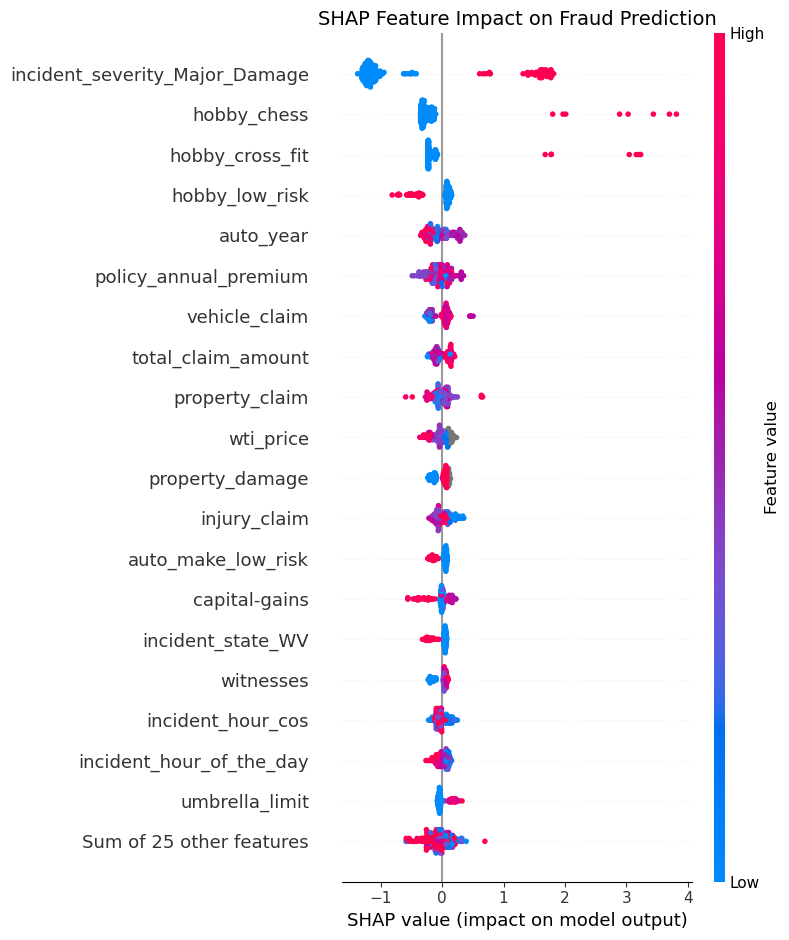

In [55]:
import shap
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Create SHAP explainer
# ---------------------------------------------------------

explainer = shap.TreeExplainer(final_xgb_model)

shap_values = explainer(X_test_final)


# ---------------------------------------------------------
# SHAP beeswarm plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    'SHAP Feature Impact on Fraud Prediction',
    fontsize=14
)

plt.tight_layout()
plt.show()

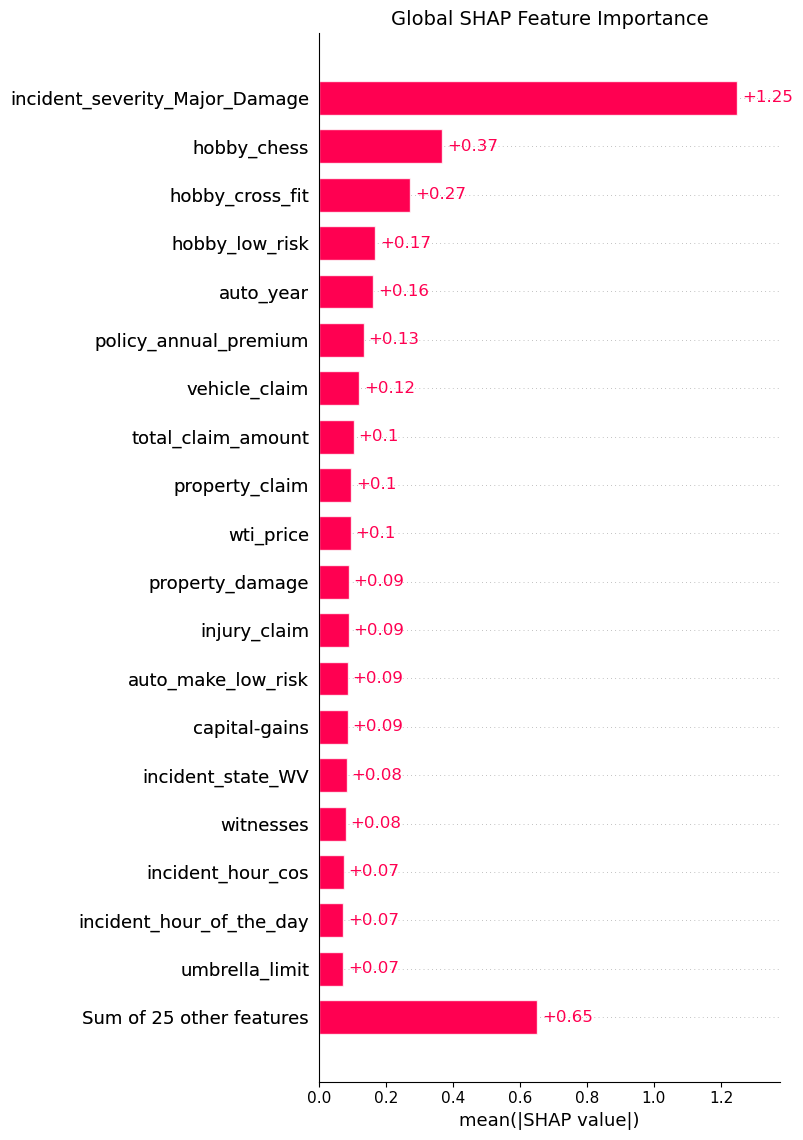

In [56]:
plt.figure(figsize=(10, 8))

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    'Global SHAP Feature Importance',
    fontsize=14
)

plt.tight_layout()
plt.show()

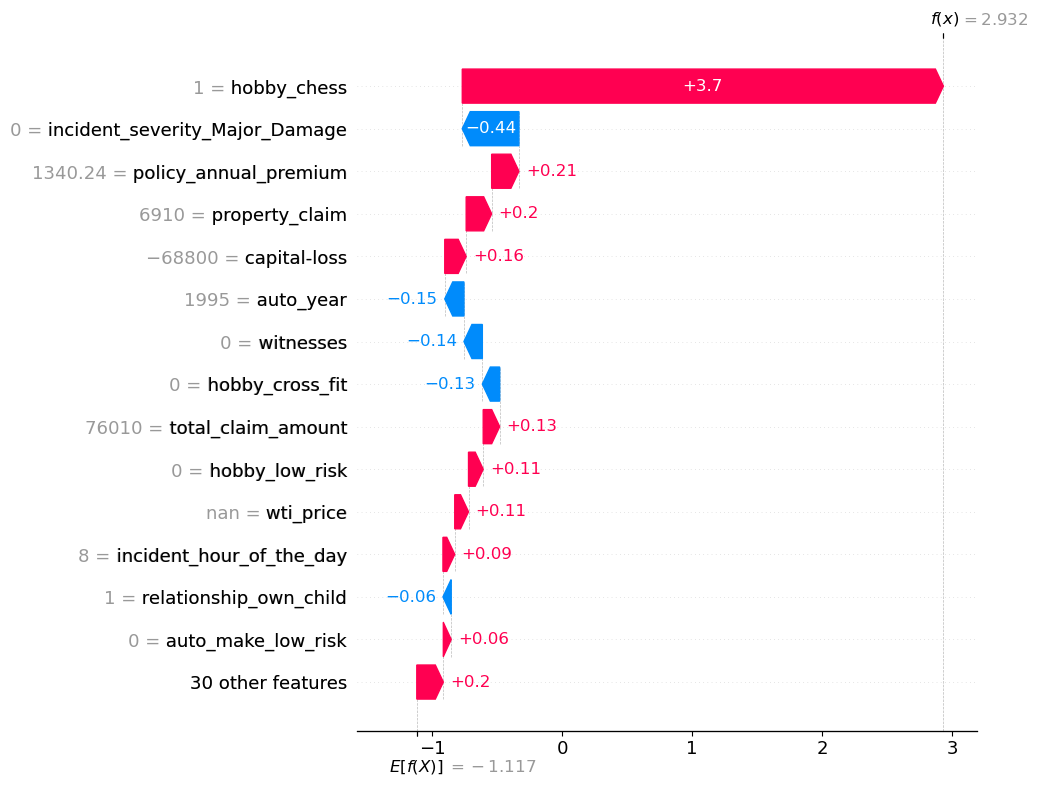

In [57]:
highest_risk_position = y_test_probability.argmax()

shap.plots.waterfall(
    shap_values[highest_risk_position],
    max_display=15
)

plt.show()

The dashboard does not only show a fraud probability. It also explains which factors pushed an individual claim toward higher or lower risk.

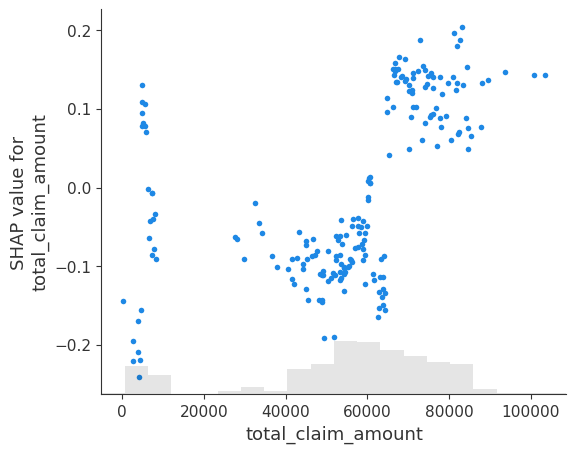

In [58]:
shap.plots.scatter(
    shap_values[:, 'total_claim_amount']
)

plt.show()

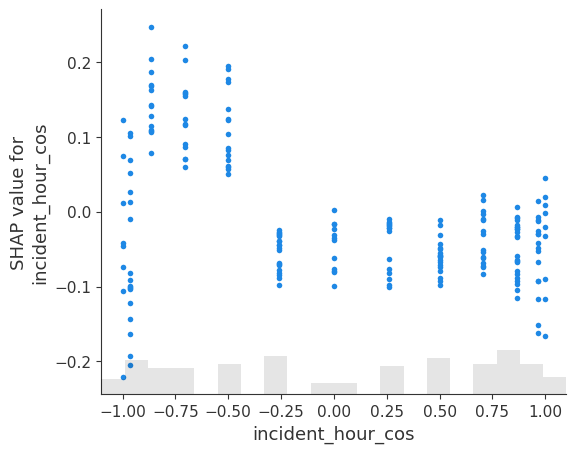

In [59]:
shap.plots.scatter(
    shap_values[:, 'incident_hour_cos']
)

plt.show()

#### Extreme Value

In [60]:
import numpy as np
import pandas as pd

extreme_value_features = [
    'months_as_customer',
    'age',
    #'policy_deductable',
    'policy_annual_premium',
    'umbrella_limit',
    'capital-gains',
    'capital-loss',
    'total_claim_amount',
    'injury_claim',
    'property_claim',
    'vehicle_claim'
]

training_data = df.loc[X_train.index]

extreme_stats = (
    training_data[extreme_value_features]
    .agg(['mean', 'std'])
    .T
    .reset_index()
    .rename(columns={
        'index': 'feature',
        'mean': 'training_mean',
        'std': 'training_std'
    })
)

extreme_stats

,feature,training_mean,training_std
0,months_as_customer,2.040012e+02,1.143090e+02
1,age,3.901625e+01,9.111243e+00
2,policy_annual_premium,1.258199e+03,2.417184e+02
3,umbrella_limit,1.077500e+06,2.257291e+06
4,capital-gains,2.454162e+04,2.768300e+04
5,capital-loss,-2.649988e+04,2.795300e+04
6,total_claim_amount,5.217380e+04,2.707221e+04
7,injury_claim,7.373562e+03,4.947459e+03
8,property_claim,7.324225e+03,4.890630e+03
9,vehicle_claim,3.747601e+04,1.930921e+04


In [61]:
extreme_records = []

stats_lookup = extreme_stats.set_index('feature')

for feature in extreme_value_features:

    mean_value = stats_lookup.loc[feature, 'training_mean']
    std_value = stats_lookup.loc[feature, 'training_std']

    if pd.isna(std_value) or std_value == 0:
        continue

    z_scores = (
        df[feature] - mean_value
    ) / std_value

    for idx, z_score in z_scores.items():

        if pd.isna(z_score):
            continue

        if z_score > 3:
            level = 'Too High'
        elif z_score > 2:
            level = 'High'
        elif z_score < -3:
            level = 'Too Low'
        elif z_score < -2:
            level = 'Low'
        else:
            continue

        extreme_records.append({
            'row_index': idx,
            'policy_number': df.loc[idx, 'policy_number'],
            'feature': feature,
            'actual_value': df.loc[idx, feature],
            'training_mean': mean_value,
            'training_std': std_value,
            'z_score': z_score,
            'extreme_level': level
        })

extreme_values = pd.DataFrame(extreme_records)

extreme_values['direction'] = np.where(
    extreme_values['z_score'] > 0,
    'Above Average',
    'Below Average'
)

extreme_values['abs_z_score'] = (
    extreme_values['z_score'].abs()
)

extreme_values['severity_rank'] = (
    extreme_values['extreme_level']
    .map({
        'Low': 1,
        'High': 1,
        'Too Low': 2,
        'Too High': 2
    })
)

extreme_values = extreme_values.sort_values(
    ['policy_number', 'abs_z_score'],
    ascending=[True, False]
)

extreme_values

,row_index,policy_number,feature,actual_value,training_mean,training_std,z_score,extreme_level,direction,abs_z_score,severity_rank
211,663,100804,umbrella_limit,6000000.00,1.077500e+06,2.257291e+06,2.180711,High,Above Average,2.180711,1
310,442,107181,property_claim,19200.00,7.324225e+03,4.890630e+03,2.428271,High,Above Average,2.428271,1
183,394,121439,umbrella_limit,7000000.00,1.077500e+06,2.257291e+06,2.623720,High,Above Average,2.623720,1
169,286,127313,umbrella_limit,6000000.00,1.077500e+06,2.257291e+06,2.180711,High,Above Average,2.180711,1
297,91,127754,property_claim,17880.00,7.324225e+03,4.890630e+03,2.158367,High,Above Average,2.158367,1
...,...,...,...,...,...,...,...,...,...,...,...
12,283,987905,months_as_customer,436.00,2.040012e+02,1.143090e+02,2.029576,High,Above Average,2.029576,1
327,850,990998,vehicle_claim,77670.00,3.747601e+04,1.930921e+04,2.081597,High,Above Average,2.081597,1
28,660,991480,months_as_customer,446.00,2.040012e+02,1.143090e+02,2.117059,High,Above Average,2.117059,1
106,447,993840,policy_annual_premium,1793.16,1.258199e+03,2.417184e+02,2.213159,High,Above Average,2.213159,1


extreme_values.to_csv(
    'extreme_value_results.csv',
    index=False
)

extreme_stats.to_csv(
    'extreme_value_thresholds.csv',
    index=False
)

#### claim-level summary table

In [62]:
extreme_summary = (
    extreme_values
    .groupby('policy_number')
    .agg(
        extreme_value_count=('feature', 'count'),
        too_extreme_count=(
            'severity_rank',
            lambda x: (x == 2).sum()
        ),
        maximum_abs_z=('abs_z_score', 'max')
    )
    .reset_index()
)

extreme_summary

,policy_number,extreme_value_count,too_extreme_count,maximum_abs_z
0,100804,1,0,2.180711
1,107181,1,0,2.428271
2,121439,1,0,2.623720
3,127313,1,0,2.180711
4,127754,1,0,2.158367
...,...,...,...,...
252,987905,2,0,2.083552
253,990998,1,0,2.081597
254,991480,1,0,2.117059
255,993840,1,0,2.213159


extreme_summary.to_csv(
    'extreme_value_summary.csv',
    index=False
)

#### Save the XGBoost final model

In [63]:
# Reference: ChatGPT

import json
from pathlib import Path

MODEL_DIR = Path("model")
MODEL_DIR.mkdir(exist_ok=True)

# Save trained XGBoost model
final_xgb_model.save_model(MODEL_DIR / "fraud_xgb_model.json")

# Save the exact feature schema expected by the model
with open(MODEL_DIR / "features.json", "w") as f:
    json.dump(stable_features, f, indent=2)

print("Model and feature schema saved.")

Model and feature schema saved.


#### Selecting a subset

In [65]:
data_sample = X_test_final.sample(5, random_state=42)
data_sample.to_csv("data/sample_inference.csv", index=False)